In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set(font_scale=1.1)

df = pd.read_csv('/content/customer_support_tickets_processed.csv')

df.head()

,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment,Resolution_Duration,Resolution_Duration_Hours,Priority_Score,type
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,Edge,PayPal,French,Afternoon,4,Small Business,3,72,4,Incident
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,Firefox,PayPal,English,Afternoon,2,Small Business,13,312,4,Problem
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,Safari,Bank Transfer,French,Morning,4,Corporate,5,120,2,Problem
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,Chrome,Credit Card,Spanish,Afternoon,7,Corporate,14,336,2,Request
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,Unknown,Debit Card,Spanish,Evening,3,Corporate,8,192,3,Request


In [ ]:
# Queue based on Ticket Category

queue_mapping = {
    'Login Issue': 'Technical Support',
    'Account Suspension': 'Account Management',
    'Payment Problem': 'Billing Support',
    'Refund Request': 'Billing Support',
    'Security Concern': 'Security Team',
    'Bug Report': 'Development Team',
    'Performance Issue': 'Infrastructure Team',
    'Feature Request': 'Product Team',
    'Data Sync Issue': 'Infrastructure Team',
    'Subscription Cancellation': 'Account Management'
}

df['Queue'] = df['category'].map(queue_mapping)

df[['category','Queue']].head()

,category,Queue
0,Account Suspension,Account Management
1,Performance Issue,Infrastructure Team
2,Performance Issue,Infrastructure Team
3,Subscription Cancellation,Account Management
4,Feature Request,Product Team


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import MiniBatchKMeans

In [7]:
# Convert issue descriptions into TF-IDF vectors

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=1000
)

X = tfidf.fit_transform(df['issue_description'])

print(X.shape)

(200000, 50)


In [8]:
# K-Means Clustering

n_clusters = 5

kmeans = MiniBatchKMeans(
    n_clusters=n_clusters,
    random_state=42,
    batch_size=1024
)

df['Cluster_ID'] = kmeans.fit_predict(X)

df[['issue_description','Cluster_ID']].head()

,issue_description,Cluster_ID
0,The payment was deducted from my bank account ...,3
1,I found a bug in the latest update affecting r...,4
2,The application crashes whenever I try to uplo...,0
3,My subscription was cancelled without my reque...,1
4,The system is not syncing data across devices ...,2


In [9]:
# K-Means Clustering

n_clusters = 5

kmeans = MiniBatchKMeans(
    n_clusters=n_clusters,
    random_state=42,
    batch_size=1024
)

df['Cluster_ID'] = kmeans.fit_predict(X)

df[['issue_description','Cluster_ID']].head()

,issue_description,Cluster_ID
0,The payment was deducted from my bank account ...,3
1,I found a bug in the latest update affecting r...,4
2,The application crashes whenever I try to uplo...,0
3,My subscription was cancelled without my reque...,1
4,The system is not syncing data across devices ...,2


In [10]:
print(df['Cluster_ID'].value_counts().sort_index())

Cluster_ID
0     19883
1     39890
2     19942
3    100378
4     19907
Name: count, dtype: int64


In [11]:
# Display Top Keywords for Each Cluster

import numpy as np

terms = tfidf.get_feature_names_out()

for i in range(n_clusters):
    print(f"\n{'='*60}")
    print(f"Cluster {i}")
    print("="*60)

    centroid = kmeans.cluster_centers_[i]
    top_terms = centroid.argsort()[-10:][::-1]

    keywords = [terms[ind] for ind in top_terms]
    print(keywords)


Cluster 0
['upload', 'try', 'crashes', 'application', 'file', 'using', 'syncing', 'update', 'unable', 'transaction']

Cluster 1
['request', 'refund', 'recent', 'like', 'charge', 'subscription', 'need', 'clarification', 'cancelled', 'upload']

Cluster 2
['properly', 'syncing', 'data', 'devices', 'upload', 'using', 'transaction', 'subscription', 'try', 'update']

Cluster 3
['account', 'statement', 'discrepancy', 'billing', 'month', 'experiencing', 'performance', 'slow', 'dashboard', 'using']

Cluster 4
['report', 'update', 'affecting', 'bug', 'latest', 'generation', 'upload', 'using', 'try', 'unable']


In [12]:
# Display Sample Tickets from Each Cluster

for i in range(n_clusters):

    print(f"\n{'#'*70}")
    print(f"CLUSTER {i}")
    print(f"{'#'*70}")

    samples = df[df['Cluster_ID'] == i]['issue_description'].head(10)

    for j, ticket in enumerate(samples, 1):
        print(f"{j}. {ticket}")


######################################################################
CLUSTER 0
######################################################################
1. The application crashes whenever I try to upload a file.
2. The application crashes whenever I try to upload a file.
3. The application crashes whenever I try to upload a file.
4. The application crashes whenever I try to upload a file.
5. The application crashes whenever I try to upload a file.
6. The application crashes whenever I try to upload a file.
7. The application crashes whenever I try to upload a file.
8. The application crashes whenever I try to upload a file.
9. The application crashes whenever I try to upload a file.
10. The application crashes whenever I try to upload a file.

######################################################################
CLUSTER 1
######################################################################
1. My subscription was cancelled without my request and I need clarification.
2. I would like

In [13]:
# Assign Cluster Names

cluster_name_mapping = {
    0: "Application Errors",
    1: "Billing & Subscription Issues",
    2: "Data Synchronization Issues",
    3: "Account & Transaction Issues",
    4: "Software Bugs & Updates"
}

df['Cluster_Name'] = df['Cluster_ID'].map(cluster_name_mapping)

# Verify
df[['Cluster_ID', 'Cluster_Name']].drop_duplicates().sort_values('Cluster_ID')

,Cluster_ID,Cluster_Name
2,0,Application Errors
3,1,Billing & Subscription Issues
4,2,Data Synchronization Issues
0,3,Account & Transaction Issues
1,4,Software Bugs & Updates


In [14]:
print(df['Cluster_Name'].value_counts())

Cluster_Name
Account & Transaction Issues     100378
Billing & Subscription Issues     39890
Data Synchronization Issues       19942
Software Bugs & Updates           19907
Application Errors                19883
Name: count, dtype: int64


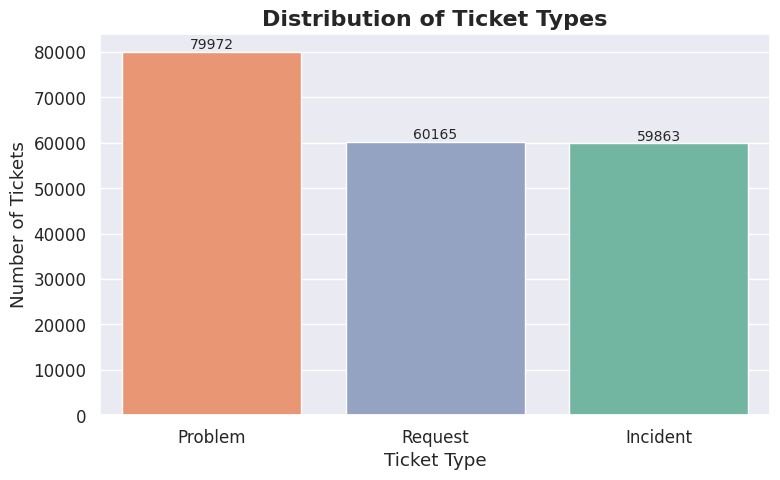

In [15]:
# Ticket Type Distribution

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='type',
    order=df['type'].value_counts().index,
    hue='type',
    palette='Set2',
    legend=False
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title('Distribution of Ticket Types', fontsize=16, fontweight='bold')
plt.xlabel('Ticket Type')
plt.ylabel('Number of Tickets')

plt.tight_layout()
plt.show()

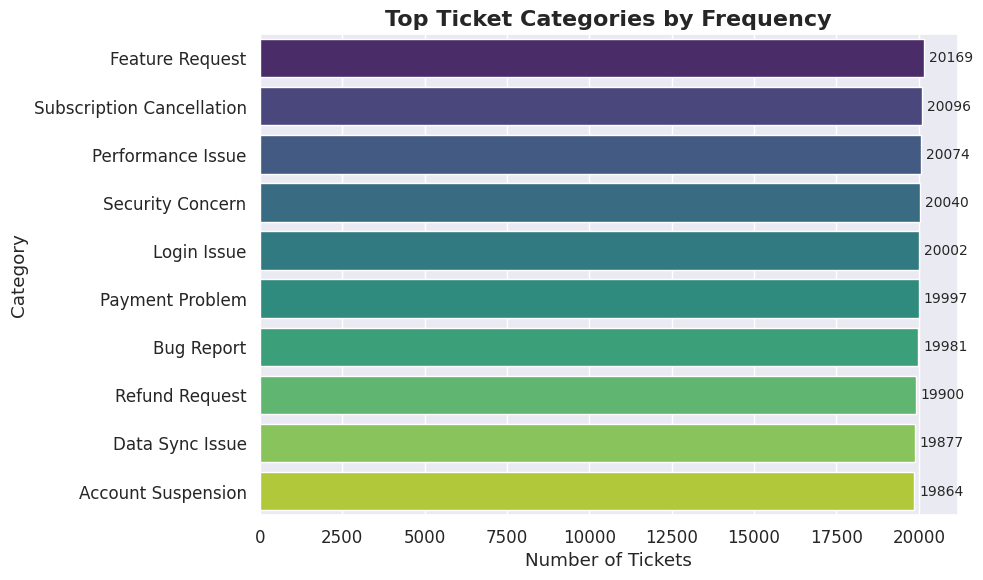

In [16]:
# Ticket Categories

category_counts = df['category'].value_counts()

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=category_counts.values,
    y=category_counts.index,
    hue=category_counts.index,
    palette='viridis',
    legend=False
)

# Add labels
for i, value in enumerate(category_counts.values):
    ax.text(value + 150,
            i,
            str(value),
            va='center',
            fontsize=10)

plt.title('Top Ticket Categories by Frequency', fontsize=16, fontweight='bold')
plt.xlabel('Number of Tickets')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

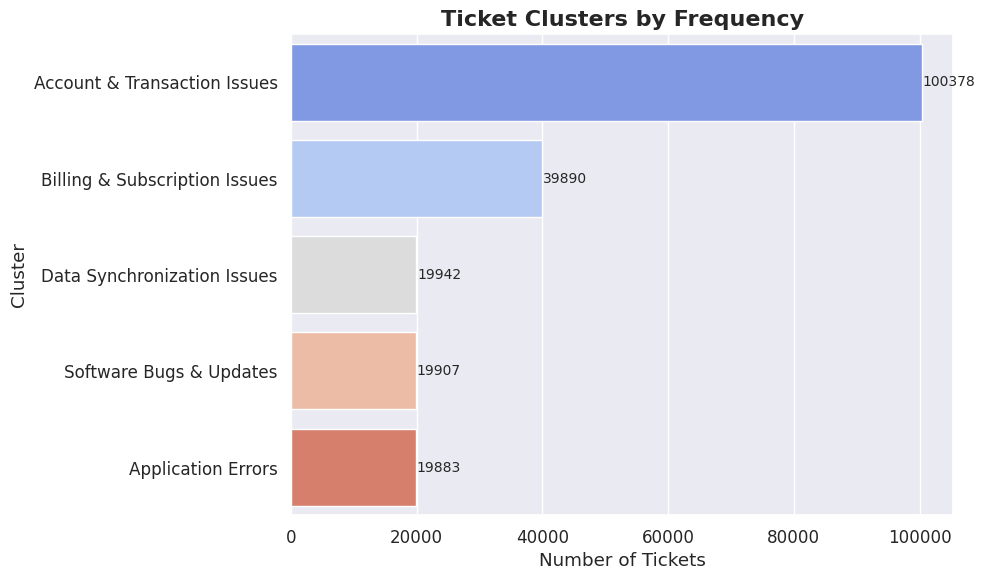

In [17]:
# Cluster Distribution

cluster_counts = df['Cluster_Name'].value_counts()

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=cluster_counts.values,
    y=cluster_counts.index,
    hue=cluster_counts.index,
    palette='coolwarm',
    legend=False
)

for i, value in enumerate(cluster_counts.values):
    ax.text(value + 150,
            i,
            str(value),
            va='center',
            fontsize=10)

plt.title('Ticket Clusters by Frequency', fontsize=16, fontweight='bold')
plt.xlabel('Number of Tickets')
plt.ylabel('Cluster')

plt.tight_layout()
plt.show()

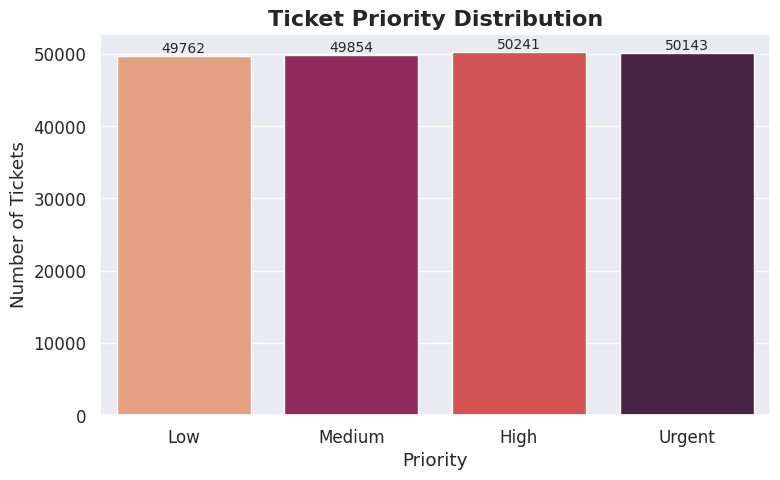

In [18]:
# Priority Distribution

priority_order = ['Low','Medium','High','Urgent']

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='priority',
    order=priority_order,
    hue='priority',
    palette='rocket',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title('Ticket Priority Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Priority')
plt.ylabel('Number of Tickets')

plt.tight_layout()
plt.show()

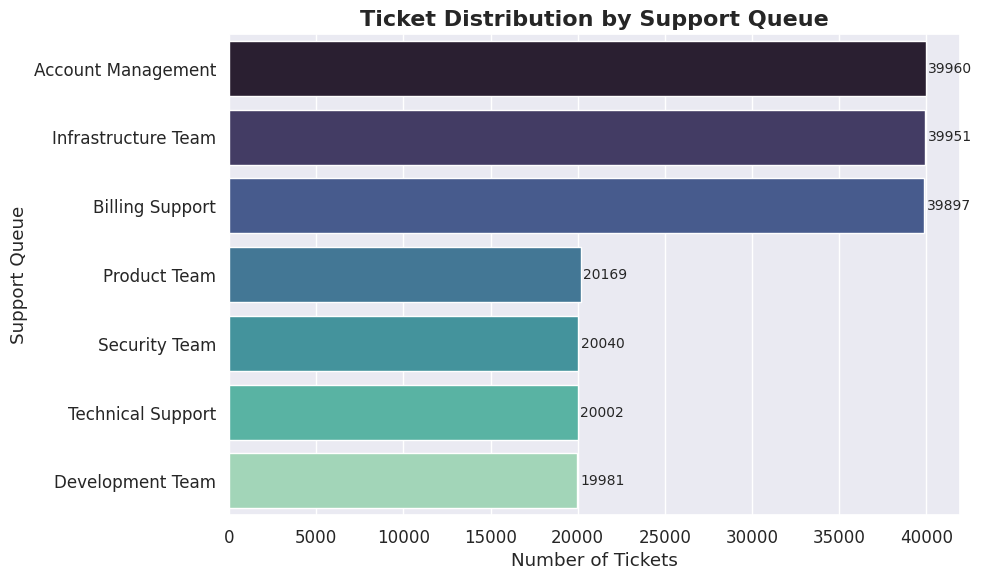

In [19]:
# Queue Distribution

queue_counts = df['Queue'].value_counts()

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=queue_counts.values,
    y=queue_counts.index,
    hue=queue_counts.index,
    palette='mako',
    legend=False
)

for i, value in enumerate(queue_counts.values):
    ax.text(value + 150,
            i,
            str(value),
            va='center',
            fontsize=10)

plt.title('Ticket Distribution by Support Queue', fontsize=16, fontweight='bold')
plt.xlabel('Number of Tickets')
plt.ylabel('Support Queue')

plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Calculate Similarity Score

similarity_scores = []

for i in range(X.shape[0]):

    cluster = df.loc[i, 'Cluster_ID']

    score = cosine_similarity(
        X[i],
        kmeans.cluster_centers_[cluster].reshape(1, -1)
    )[0][0]

    similarity_scores.append(score)

df['Similarity_Score'] = similarity_scores

df[['Cluster_ID','Similarity_Score']].head()

,Cluster_ID,Similarity_Score
0,3,0.484846
1,4,1.000000
2,0,1.000000
3,1,0.744156
4,2,1.000000


In [21]:
# Similarity Level

def similarity_level(score):

    if score >= 0.70:
        return 'High'

    elif score >= 0.40:
        return 'Medium'

    else:
        return 'Low'


df['Similarity_Level'] = df['Similarity_Score'].apply(similarity_level)

df[['Similarity_Score','Similarity_Level']].head()

,Similarity_Score,Similarity_Level
0,0.484846,Medium
1,1.000000,High
2,1.000000,High
3,0.744156,High
4,1.000000,High


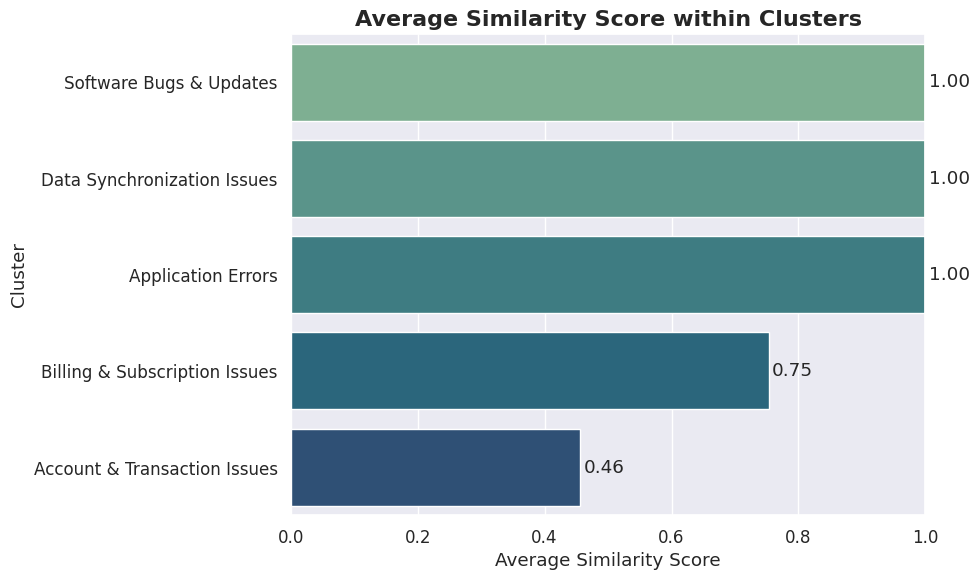

In [22]:
# Average Similarity Score by Cluster

cluster_similarity = (
    df.groupby('Cluster_Name')['Similarity_Score']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=cluster_similarity.values,
    y=cluster_similarity.index,
    hue=cluster_similarity.index,
    palette='crest',
    legend=False
)

# Labels
for i, value in enumerate(cluster_similarity.values):
    ax.text(value + 0.005,
            i,
            f"{value:.2f}",
            va='center')

plt.title('Average Similarity Score within Clusters',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Average Similarity Score')
plt.ylabel('Cluster')

plt.xlim(0,1)

plt.tight_layout()
plt.show()

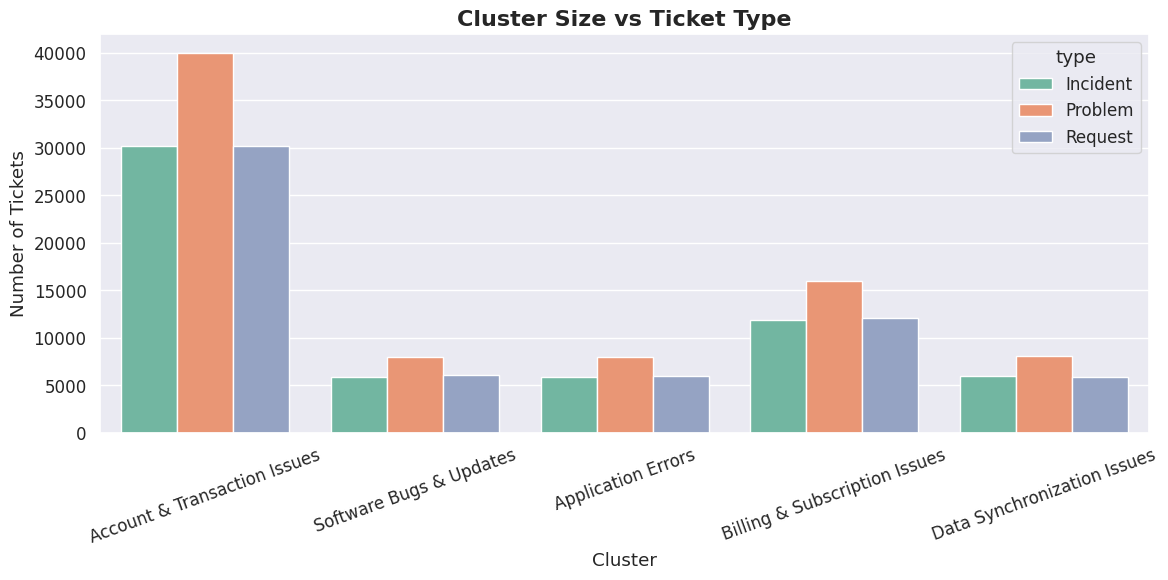

In [23]:
# Cluster Size vs Ticket Type

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='Cluster_Name',
    hue='type',
    palette='Set2'
)

plt.title('Cluster Size vs Ticket Type',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Cluster')
plt.ylabel('Number of Tickets')

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

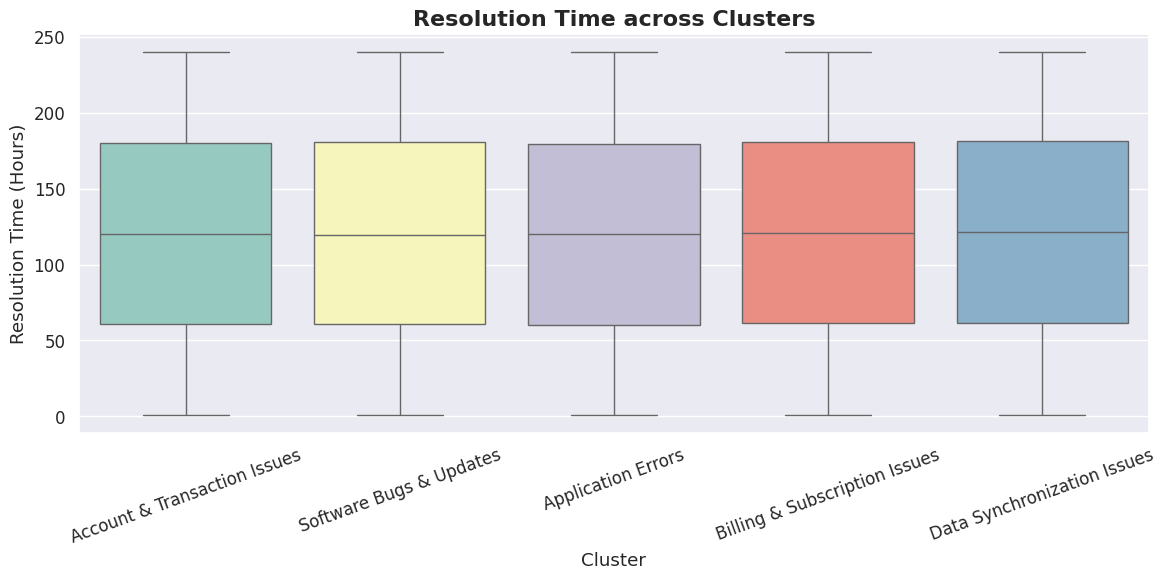

In [24]:
# Resolution Time by Cluster

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Cluster_Name',
    y='resolution_time_hours',
    hue='Cluster_Name',
    palette='Set3',
    legend=False
)

plt.title('Resolution Time across Clusters',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Cluster')
plt.ylabel('Resolution Time (Hours)')

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

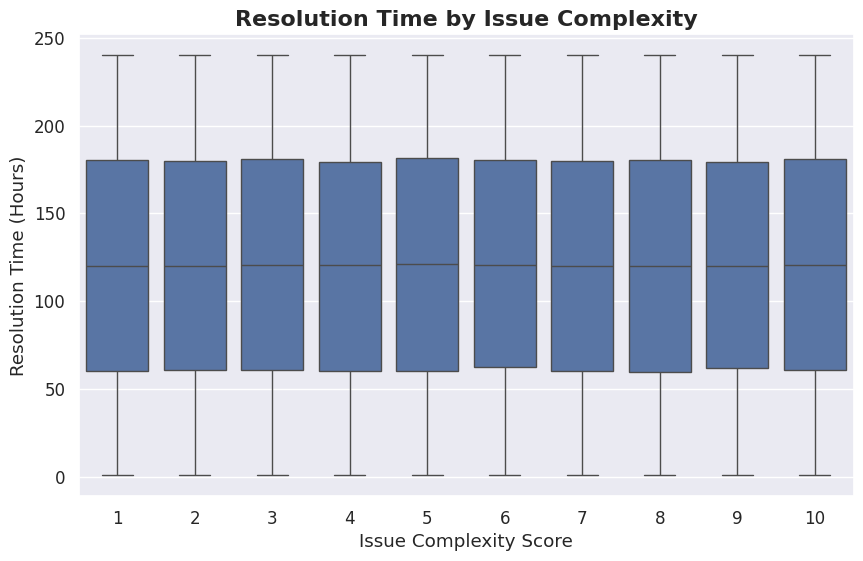

In [25]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='issue_complexity_score',
    y='resolution_time_hours'
)

plt.title('Resolution Time by Issue Complexity',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Issue Complexity Score')
plt.ylabel('Resolution Time (Hours)')

plt.show()

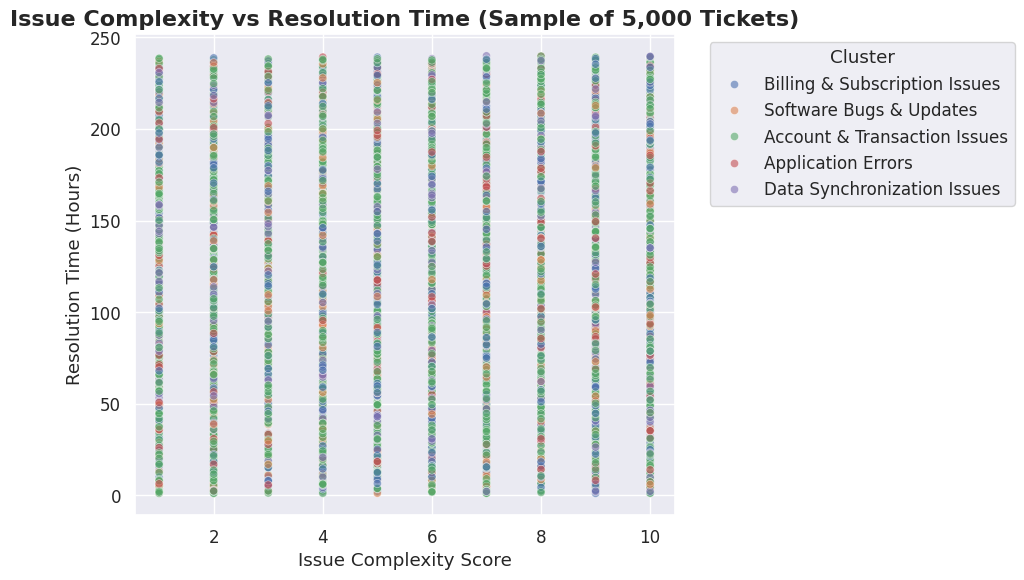

In [26]:
# Random sample for visualization
sample_df = df.sample(n=5000, random_state=42)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_df,
    x='issue_complexity_score',
    y='resolution_time_hours',
    hue='Cluster_Name',
    alpha=0.6,
    s=35
)

plt.title(
    'Issue Complexity vs Resolution Time (Sample of 5,000 Tickets)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Issue Complexity Score')
plt.ylabel('Resolution Time (Hours)')

plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()